# Import Statements

In [9]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [3]:
import pandas as pd
import numpy as np
import sklearn

from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns


/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.linear_model import Lasso

from sklearn.metrics import accuracy_score


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
import tqdm as notebook_tqdm
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [7]:
from platform import python_version

print(python_version())


3.10.12


In [30]:
print(np.__version__)

1.26.3


# Define all functions

In [7]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}

# set parameter space for LASSO

lasso_space = {
    'alpha': Real(1e-5, 1.0, 'log-uniform')  # L1 penalty term
}

In [8]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [9]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [10]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [11]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [8]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [13]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [14]:
#Load file
tt_prt = pd.read_pickle("pickle_files/training_data_prt.pkl")
tt_prt.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [15]:
#Extract only SNPs for feature selection

In [16]:
feature= tt_prt.iloc[:, 1:251229]
feature.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s101_HeiLongJiang_2014,0,0,1,0,0,1,1,0,0,0,...,2,0,1,0,0,2,2,0,2,0


In [17]:
target = tt_prt["PRT"]
target.head()

new_line
s100_BeiJing_2013         340.553
s100_HeNan_2014           358.104
s1014_BeiJing_2013        366.116
s1014_HeNan_2014          326.667
s101_HeiLongJiang_2014    385.915
Name: PRT, dtype: float64

In [18]:
cov = tt_prt.iloc[:,-10:]
cov.head()

,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,
s100_BeiJing_2013,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [75]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [38]:
# If you want to run bayessearch CV for the full training, split the dataset and run like so 
from sklearn.pipeline import make_pipeline
def run_bayes_lasso_on_feature_subsets(X, y, n_splits=8):
    # Split features horizontally into subsets
    feature_subsets = np.array_split(X, n_splits, axis=1)
    best_models = []
    
    for i, X_subset in enumerate(feature_subsets):
        print(f"\Feature Subset {i+1}/{n_splits}: Shape = {X_subset.shape}")

        # Define pipeline: StandardScaler + Lasso
        lasso_pipeline = make_pipeline(
            Lasso(max_iter=100000)
        )

        # Define hyperparameter search space
        param_search = {
            'lasso__alpha': Real(1e-5, 1.0, prior='log-uniform')
        }

        # Create BayesSearchCV
        bayes_cv = BayesSearchCV(
            lasso_pipeline,
            search_spaces=param_search,
            n_iter=10,
            cv=3,
            scoring=None,
            n_jobs=-1,
            verbose=1,
            random_state=42
        )

        # Fit
        bayes_cv.fit(X_subset, y)
        print(f"Best alpha: {bayes_cv.best_params_['lasso__alpha']:.5f}")
        
        # Save the best model
        best_models.append(bayes_cv.best_estimator_)

    return best_models

#best_lasso = run_bayes_lasso_on_feature_subsets(X_train, y_train, n_splits=8)

In [76]:
X_train_subset = X_train.iloc[:, :1000]
X_train_subset.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr1_4969562,Chr1_4982468,Chr1_4988225,Chr1_4990892,Chr1_5004708,Chr1_5007930,Chr1_5012238,Chr1_5022900,Chr1_5022975,Chr1_5023098
new_line,,,,,,,,,,,,,,,,,,,,,
s1055_HeNan_2014,0,0,0,0,0,0,0,0,0,1,...,2,0,0,0,0,0,0,0,0,0
s665_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
s843_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,2,0,0,0,0,0
s698_HeiLongJiang_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s576_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [77]:
best_lasso = bayesian_lasso_search(X_train_subset, y_train, lasso_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.794e+04, tolerance: 4.160e+01
  model = cd_fast.enet_coordinate_descent(
/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.390e+04, tolerance: 4.344e+01
  model = cd_fast.enet_coordinate_descent(
/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Du

Best Lasso hyperparameters: OrderedDict([('alpha', 0.5989491205267933)])


/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.896e+04, tolerance: 4.249e+01
  model = cd_fast.enet_coordinate_descent(


In [19]:
# Create a Lasso Regression model with the best parameters from bayes CV
#alpha = 0.5989  # Regularization strength (adjust from best_params)
alpha = 0.7352
best_lasso_model = Lasso(alpha=alpha)

# Fit the model to the full training data
best_lasso_model.fit(feature, target)

Lasso(alpha=0.7352)

In [20]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['Chr1_15246' 'Chr1_17750' 'Chr1_23692' ... 'Chr20_52266575'
 'Chr20_52267177' 'Chr20_52267897']


In [21]:
# Using np.abs() to make coefficients positive.  
lasso_coef = np.abs(best_lasso_model.coef_)

In [22]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = lasso_coef != 0

In [23]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [24]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [25]:
new_data = tt_prt[selected_feature]
print(new_data.head())

                        Chr1_1046903  Chr1_1051280  Chr1_1956216  \
new_line                                                           
s100_BeiJing_2013                  2             0             0   
s100_HeNan_2014                    2             0             0   
s1014_BeiJing_2013                 0             0             0   
s1014_HeNan_2014                   0             0             0   
s101_HeiLongJiang_2014             2             0             2   

                        Chr1_2024622  Chr1_8233655  Chr1_31998254  \
new_line                                                            
s100_BeiJing_2013                  0             0              0   
s100_HeNan_2014                    0             0              0   
s1014_BeiJing_2013                 0             0              0   
s1014_HeNan_2014                   0             0              0   
s101_HeiLongJiang_2014             2             0              2   

                        Chr1_46155815  

In [26]:
new_data.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_2406752,Chr20_3272852,Chr20_4691294,Chr20_15867030,Chr20_23836589,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s100_HeNan_2014,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s101_HeiLongJiang_2014,2,0,2,2,0,2,0,2,0,0,...,2,0,0,1,0,1,0,0,2,0


In [27]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 290 entries, Chr1_1046903 to Chr20_50084112
dtypes: int64(290)
memory usage: 2.5+ MB


In [28]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,2,0,0,0,0,0,0,2,0,2,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,2,0,0,0,0,0,0,2,0,2,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,2,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,2,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,2,0,2,2,0,2,0,2,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [29]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 300 entries, Chr1_1046903 to PRT
dtypes: float64(4), int64(296)
memory usage: 2.5+ MB


In [30]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,2,0,0,0,0,0,0,2,0,2,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,0,0,0,0,0,0,0,0,0,2,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,2,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,2,0,2,2,0,2,0,2,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [31]:
fs_data.to_pickle("fs_prt_lasso_training_data_new.pkl")

In [10]:
fs_data = pd.read_pickle("../pickle_files/fs_prt_lasso_training_data_new.pkl")

In [32]:

fs_data.to_csv("fs_prt_lasso_training_data_new.txt")

In [33]:
## All traits

In [11]:
X_all = fs_data.drop("PRT", axis=1).values
y_all = fs_data["PRT"].values

In [12]:
X_dupe = fs_data.drop("PRT", axis=1)
X_dupe.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_50084112,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,2,0,0,0,0,0,0,2,0,2,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,2,0,2,2,0,2,0,2,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [14]:
X_train.shape

(984, 299)

In [131]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.564108022845424), ('colsample_bytree', 0.6911050210594937), ('gamma', 0.49999999999999994), ('learning_rate', 0.3258517590992736), ('max_delta_step', 2), ('max_depth', 50), ('min_child_weight', 3), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 46.625650568707975), ('subsample', 0.06424522118479445)])


In [132]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.8085213723181941
RMSE for dataset is:19.816835646118527& mean of this fold is 354.5001
this is 5.590079000293238% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5608754972419412
RMSE for dataset is:17.277317158849137& mean of this fold is 353.36984545454544
this is 4.889301501271293% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.256849201655871
RMSE for dataset is:18.245467192152603& mean of this fold is 352.8150272727272
this is 5.171397412743646% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.8704400939300316
RMSE for dataset is:19.917839369928284& mean of this fold is 348.4073181818182
this is 5.7168257756095855% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.9791563882769974
RMSE for dataset 

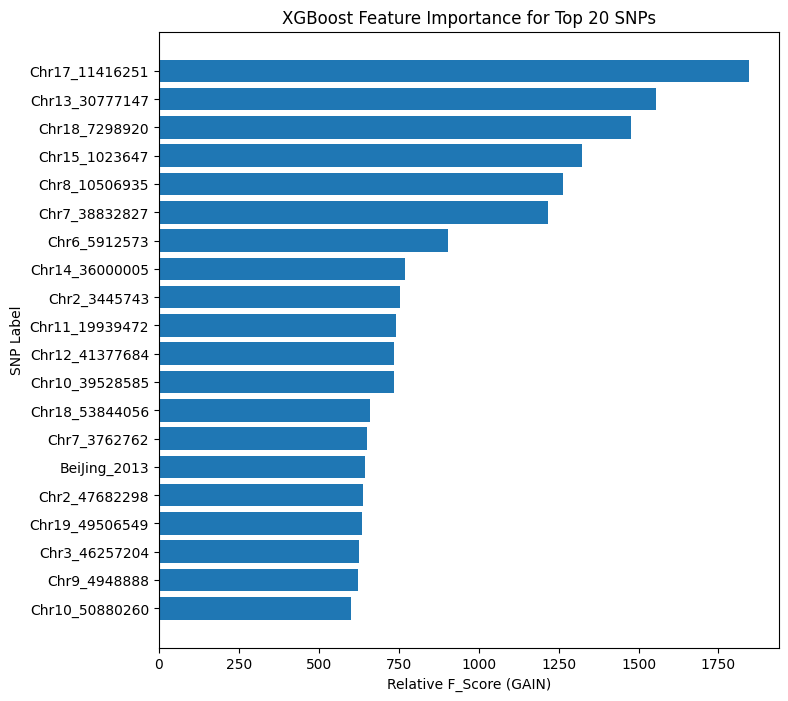

In [40]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_dupe, top_n=20)

In [41]:
explainer = shap.Explainer(best_xgbr_model)

In [42]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

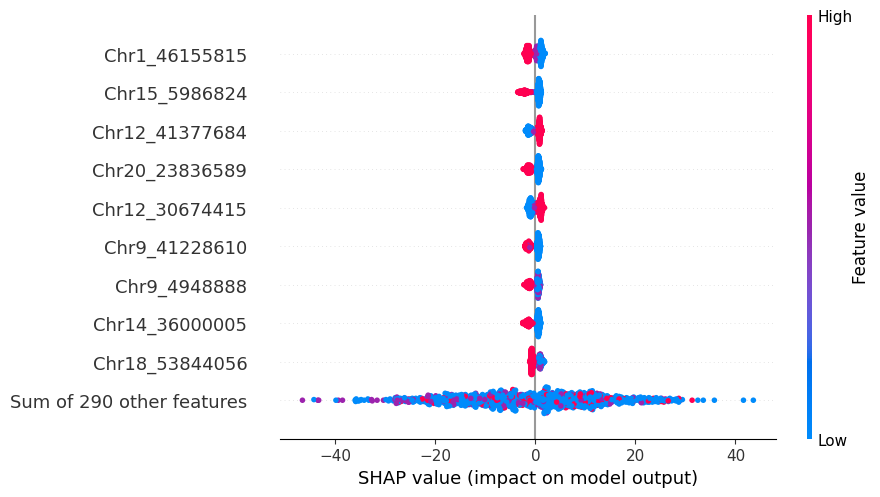

In [43]:
shap.plots.beeswarm(shap_values, show=False)

In [15]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [16]:
holdout_data = holdout_data.set_index('Line')

In [17]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [18]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [19]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [20]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [21]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 299 entries, Chr1_1046903 to landrace
dtypes: float64(3), int64(296)
memory usage: 642.2+ KB


In [22]:
y_holdout.shape

(274, 1)

In [23]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [140]:
pickle.dump(best_xgbr_model, open("lasso_allfeats_xgbr_prt.pickle.dat", "wb"))

In [24]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/lasso_allfeats_xgbr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.13
RMSE of Holdout: 23.42
Mean of Holdout: 355.60
This is 6.59% of the mean pheno data
0 355.712 374.39307
1 344.136 362.86896
2 351.481 370.675
3 353.611 367.7129
4 390.342 353.77295


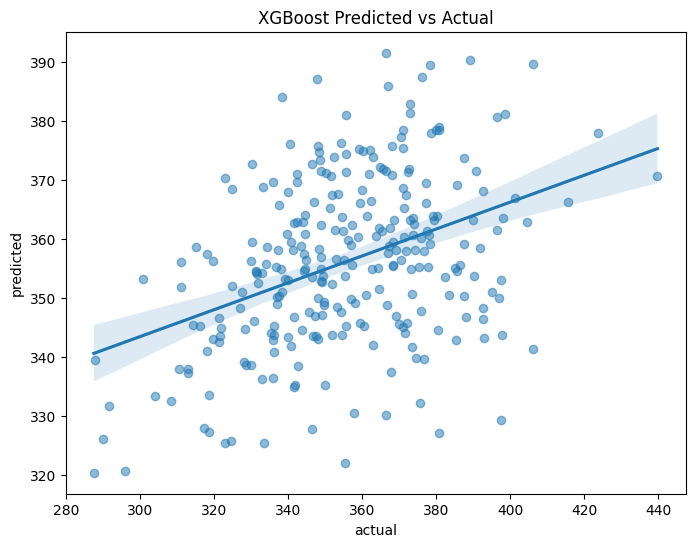

In [25]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [141]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 21), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [142]:
best_rfr_model = eval_k_fold(best_rfreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.715244138049238
RMSE for dataset is:22.427872692670288& mean of this fold is 351.3487727272727
this is 6.3833644610677105% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.901500492986819
RMSE for dataset is:20.266693787946316& mean of this fold is 355.9080727272727
this is 5.694361926844069% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.7202545423766833
RMSE for dataset is:22.355233494741036& mean of this fold is 359.3171454545454
this is 6.2215883036867305% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.4255175517266907
RMSE for dataset is:21.371621317707607& mean of this fold is 355.1499545454545
this is 6.017633127691227% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.125964686365189
RMSE for d

In [58]:
pickle.dump(best_rfr_model, open("lasso_allfeats_rfr_prt.pickle.dat", "wb"))

In [26]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/lasso_allfeats_rfr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.15
RMSE of Holdout: 23.15
Mean of Holdout: 355.60
This is 6.51% of the mean pheno data
0 355.712 352.709490056689
1 344.136 355.49319365079367
2 351.481 359.1542484920637
3 353.611 364.00688119047595
4 390.342 359.6267627777777


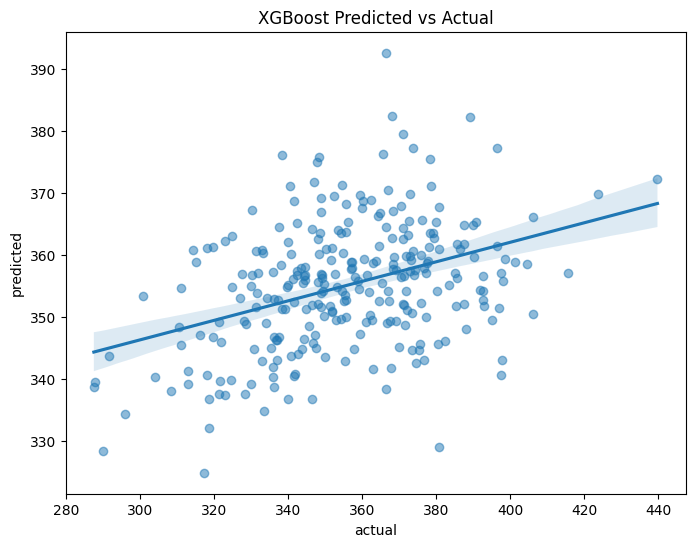

In [27]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [59]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [60]:
best_svr_model = eval_k_fold(best_svreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3041025824475687
RMSE for dataset is:18.283068350207497& mean of this fold is 352.7580363636363
this is 5.182892086223266% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.05862413856210935
RMSE for dataset is:22.025010850335356& mean of this fold is 353.8857545454545
this is 6.223763055572889% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.32538067089091427
RMSE for dataset is:18.333457222470344& mean of this fold is 354.27561818181823
this is 5.174913621366235% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.10954064219020254
RMSE for dataset is:18.99306817748746& mean of this fold is 350.83194545454535
this is 5.413722559637389% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.11937159990261059
RMSE for

In [62]:
pickle.dump(best_svr_model, open("lasso_allfeats_svr_prt.pickle.dat", "wb"))

In [28]:
best_svr_model = pickle.load(open("../pickle_bestmodels/lasso_allfeats_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: -0.06
RMSE of Holdout: 25.85
Mean of Holdout: 355.60
This is 7.27% of the mean pheno data
0 355.712 390.7872684612054
1 344.136 339.7552097655613
2 351.481 362.51181187066106
3 353.611 373.4750235381613
4 390.342 352.6819263452104


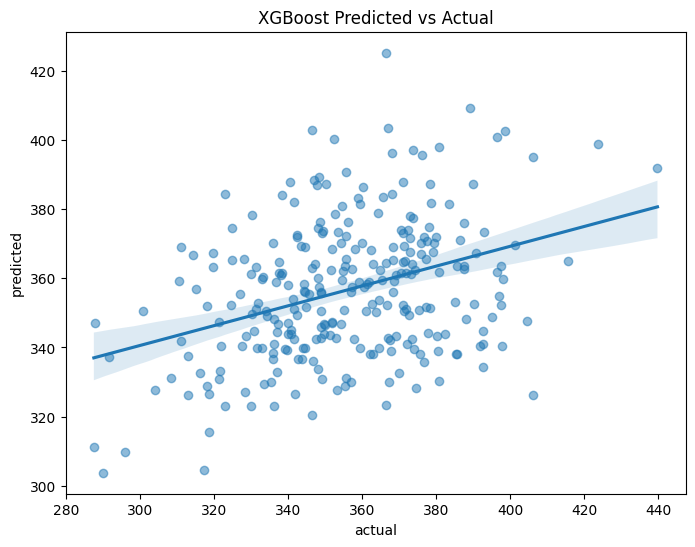

In [29]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only Location

In [30]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,1,0,0,0,1
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,0,1,0,0,1
s101,2,0,2,2,0,2,0,2,0,0,...,1,0,0,2,0,0,0,1,0,1


In [31]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 295 entries, Chr1_1046903 to landrace
dtypes: int64(295)
memory usage: 2.5+ MB


In [32]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
snps_loc_dupe.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,1,0,0,0,1
s100,2,0,0,0,0,0,0,2,0,2,...,1,0,0,0,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,2,...,0,2,2,0,0,0,1,0,0,1
s101,2,0,2,2,0,2,0,2,0,0,...,1,0,0,2,0,0,0,1,0,1


In [33]:
y_all = fs_data["PRT"].values

In [67]:
# Split training set into training and validation

In [68]:
X_train, X_test, y_train, y_test = train_test_split(snps_loc, y_all, test_size=0.1, random_state=42)

In [69]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [70]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.01), ('colsample_bytree', 0.8849207121813458), ('gamma', 0.49999999999999994), ('learning_rate', 0.5811709026674674), ('max_delta_step', 0), ('max_depth', 18), ('min_child_weight', 0), ('n_estimators', 186), ('reg_alpha', 1.0), ('reg_lambda', 1000.0), ('subsample', 0.8923762087894971)])


In [71]:
snps_loc = snps_loc.to_numpy()
#y_all = y_all.to_numpy()
best_xgbr_model = eval_k_fold(best_xgbreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.154585772827518
RMSE for dataset is:19.326903399953185& mean of this fold is 352.97114545454554
this is 5.475491027762223% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.695577176457324
RMSE for dataset is:17.91371737995442& mean of this fold is 352.83067272727277
this is 5.077142880319017% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3491397439834993
RMSE for dataset is:21.054364176436707& mean of this fold is 347.4561272727272
this is 6.05957487113491% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.6353389138856782
RMSE for dataset is:20.196631346165212& mean of this fold is 352.74611818181813
this is 5.725543189607869% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.4623426390210983
RMSE for d

In [34]:
#pickle.dump(best_xgbr_model, open("lasso_onlyloc_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/lasso_onlyloc_xgbr_prt.pickle.dat", "rb"))

In [35]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, snps_loc_dupe, top_n=20)

NameError: name 'plot_xgb_feature_importance' is not defined

In [74]:
explainer = shap.Explainer(best_xgbr_model)

In [75]:
shap_values = explainer(snps_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

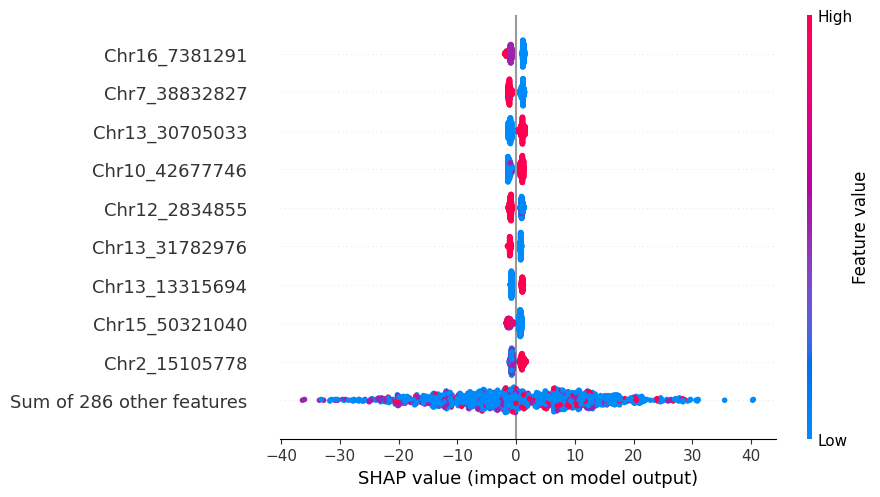

In [76]:
shap.plots.beeswarm(shap_values, show=False)

In [77]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [78]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [36]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [37]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [38]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [39]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 295 entries, Chr1_1046903 to landrace
dtypes: int64(295)
memory usage: 633.6+ KB


In [40]:
X_holdout.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,2,0,2,2,0,2,0,2,0,0,...,1,0,0,2,0,1,0,0,0,1
s102,2,0,0,2,2,0,0,2,0,0,...,2,0,0,0,0,0,0,1,0,1
s110,0,0,0,0,0,0,2,2,0,2,...,2,2,0,0,0,1,0,0,0,1
s112,2,2,0,0,0,1,2,2,1,1,...,1,2,2,0,2,1,0,0,0,1
s113,0,0,0,0,0,0,0,2,0,2,...,0,2,0,0,2,1,0,0,0,1


In [41]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.16
RMSE of Holdout: 22.92
Mean of Holdout: 355.60
This is 6.45% of the mean pheno data
0 355.712 355.62405
1 344.136 357.9013
2 351.481 360.10144
3 353.611 363.17737
4 390.342 359.04974


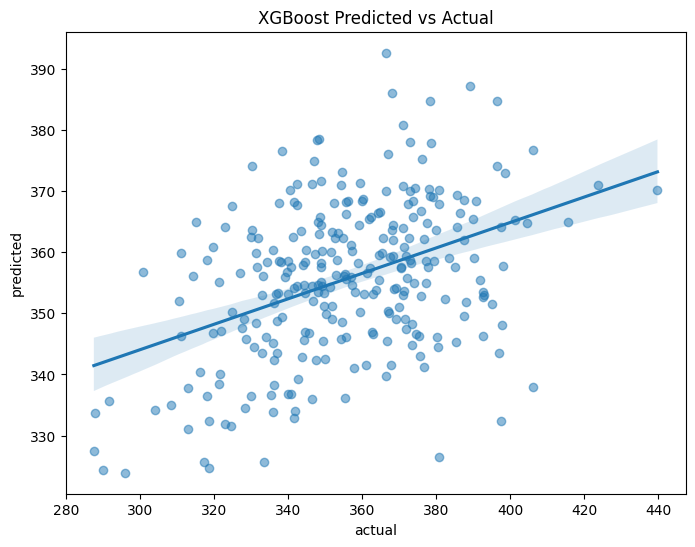

In [42]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [86]:
 # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 355.712 355.62405
1 344.136 357.9013
2 351.481 360.10144
3 353.611 363.17737
4 390.342 359.04974
5 358.958 358.19962


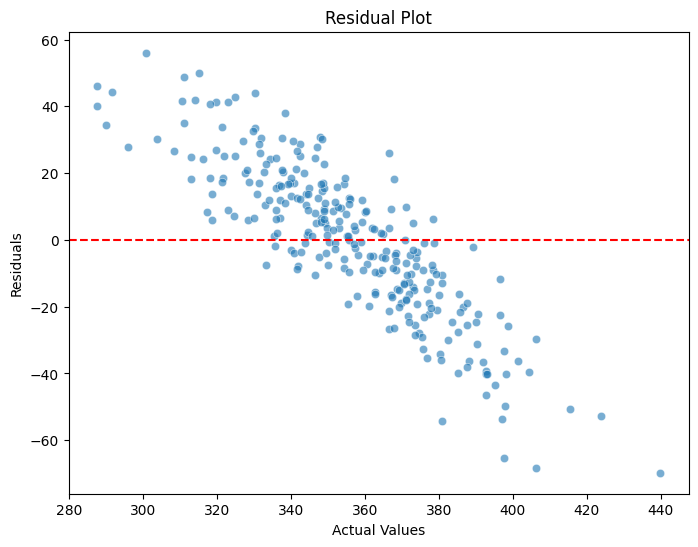

In [87]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [88]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 27), ('max_features', 'sqrt'), ('max_samples', 0.6886079110650399), ('min_samples_leaf', 3), ('min_samples_split', 9), ('n_estimators', 273)])


In [89]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.282370432075169
RMSE for dataset is:22.51922452569954& mean of this fold is 354.5000181818181
this is 6.352390231514668% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.3031780136763897
RMSE for dataset is:20.497278301355276& mean of this fold is 355.34837272727276
this is 5.768220674275266% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.9066510278782443
RMSE for dataset is:21.40870920970879& mean of this fold is 351.4421636363636
this is 6.091673516971723% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.4512855841035277
RMSE for dataset is:19.33067747607946& mean of this fold is 356.19880000000006
this is 5.426935036299802% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.4089453856156413
RMSE for da

In [90]:
pickle.dump(best_rfr_model, open("lasso_onlyloc_rfr_prt.pickle.dat", "wb"))

In [43]:
best_rfr_model= pickle.load(open("../pickle_bestmodels/lasso_onlyloc_rfr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.17
RMSE of Holdout: 22.79
Mean of Holdout: 355.60
This is 6.41% of the mean pheno data
0 355.712 352.90079359800734
1 344.136 354.9553535959939
2 351.481 361.2166772287592
3 353.611 366.1042414303752
4 390.342 360.24577335453057


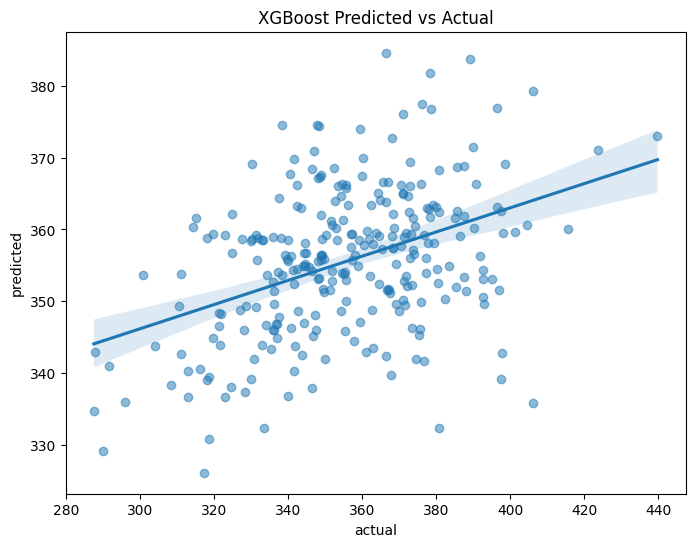

In [44]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [92]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [93]:
best_svr_model = eval_k_fold(best_svreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6613577906777632
RMSE for dataset is:15.560468490185679& mean of this fold is 354.90826363636364
this is 4.384363534045186% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.1744359671708526
RMSE for dataset is:19.059904524403755& mean of this fold is 355.83059999999995
this is 5.35645459508085% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.658767150386712
RMSE for dataset is:19.149660720046118& mean of this fold is 351.4692
this is 5.4484605535979025% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.6739150963977911
RMSE for dataset is:20.29923848070716& mean of this fold is 354.37173636363633
this is 5.728232925403855% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.225792114226035
RMSE for dataset i

In [94]:
pickle.dump(best_svr_model, open("lasso_onlyloc_svr_prt.pickle.dat", "wb"))

In [45]:
best_svr_model = pickle.load(open("../pickle_bestmodels/lasso_onlyloc_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.16
RMSE of Holdout: 22.98
Mean of Holdout: 355.60
This is 6.46% of the mean pheno data
0 355.712 367.4429033637849
1 344.136 357.51606466916814
2 351.481 361.6452729888126
3 353.611 367.17317691859836
4 390.342 355.9302864802108


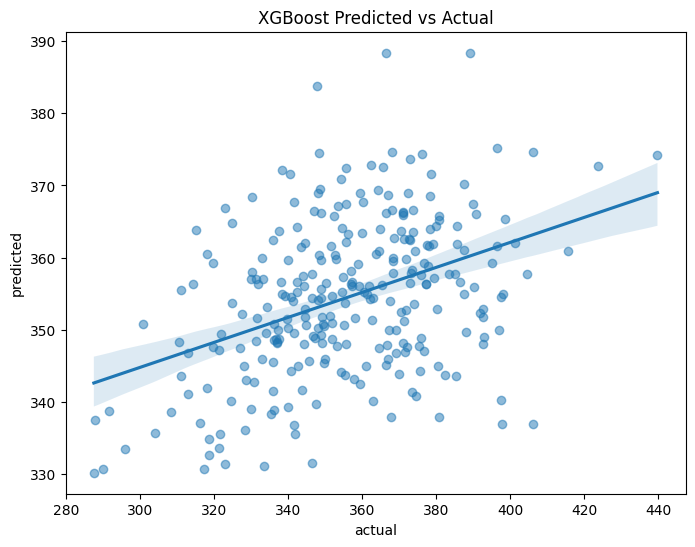

In [46]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only snps

In [47]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 300 entries, Chr1_1046903 to PRT
dtypes: float64(4), int64(296)
memory usage: 2.5+ MB


In [48]:
only_snps = fs_data.iloc[:, 0:290]
only_snps.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_2406752,Chr20_3272852,Chr20_4691294,Chr20_15867030,Chr20_23836589,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s101,2,0,2,2,0,2,0,2,0,0,...,2,0,0,1,0,1,0,0,2,0


In [49]:
only_snps_dupe = fs_data.iloc[:, 0:290]
only_snps.head()

,Chr1_1046903,Chr1_1051280,Chr1_1956216,Chr1_2024622,Chr1_8233655,Chr1_31998254,Chr1_46155815,Chr1_51448294,Chr1_55253566,Chr1_56403929,...,Chr20_2406752,Chr20_3272852,Chr20_4691294,Chr20_15867030,Chr20_23836589,Chr20_40346647,Chr20_40962479,Chr20_45033350,Chr20_48338919,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s100,2,0,0,0,0,0,0,2,0,2,...,2,0,1,0,0,1,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s1014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,2,2,0,0
s101,2,0,2,2,0,2,0,2,0,0,...,2,0,0,1,0,1,0,0,2,0


In [50]:
y_all = fs_data["PRT"]
y_all.head()

Line
s100     340.553
s100     358.104
s1014    366.116
s1014    326.667
s101     385.915
Name: PRT, dtype: float64

### Run models

In [102]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [103]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [104]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 0.01), ('gamma', 0.49999999999999994), ('learning_rate', 1.0), ('max_delta_step', 0), ('max_depth', 0), ('min_child_weight', 10), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1000.0), ('subsample', 1.0)])


In [105]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.771398275507786
RMSE for dataset is:18.83766408055583& mean of this fold is 356.12672727272735
this is 5.289595707914856% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.93911571908043
RMSE for dataset is:19.92815429759938& mean of this fold is 351.8479999999999
this is 5.663853225710929% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.4671408477653525
RMSE for dataset is:19.20036556226826& mean of this fold is 355.4500545454546
this is 5.401705617072268% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.12839705160739423
RMSE for dataset is:17.904149569290777& mean of this fold is 355.6441
this is 5.034288371237081% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5259886011132757
RMSE for dataset is:19

In [106]:
pickle.dump(best_xgbr_model, open("lasso_onlysnps_xgbr_PRT.pickle.dat", "wb"))

In [51]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/lasso_onlysnps_xgbr_PRT.pickle.dat", "rb"))

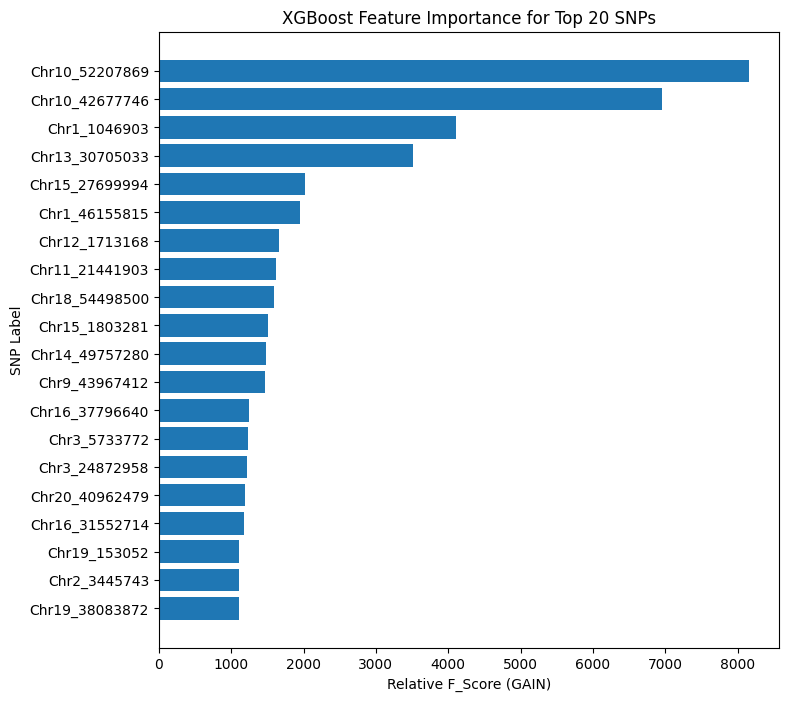

In [107]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20)

In [108]:
explainer = shap.Explainer(best_xgbr_model)

In [109]:
shap_values = explainer(only_snps_dupe)

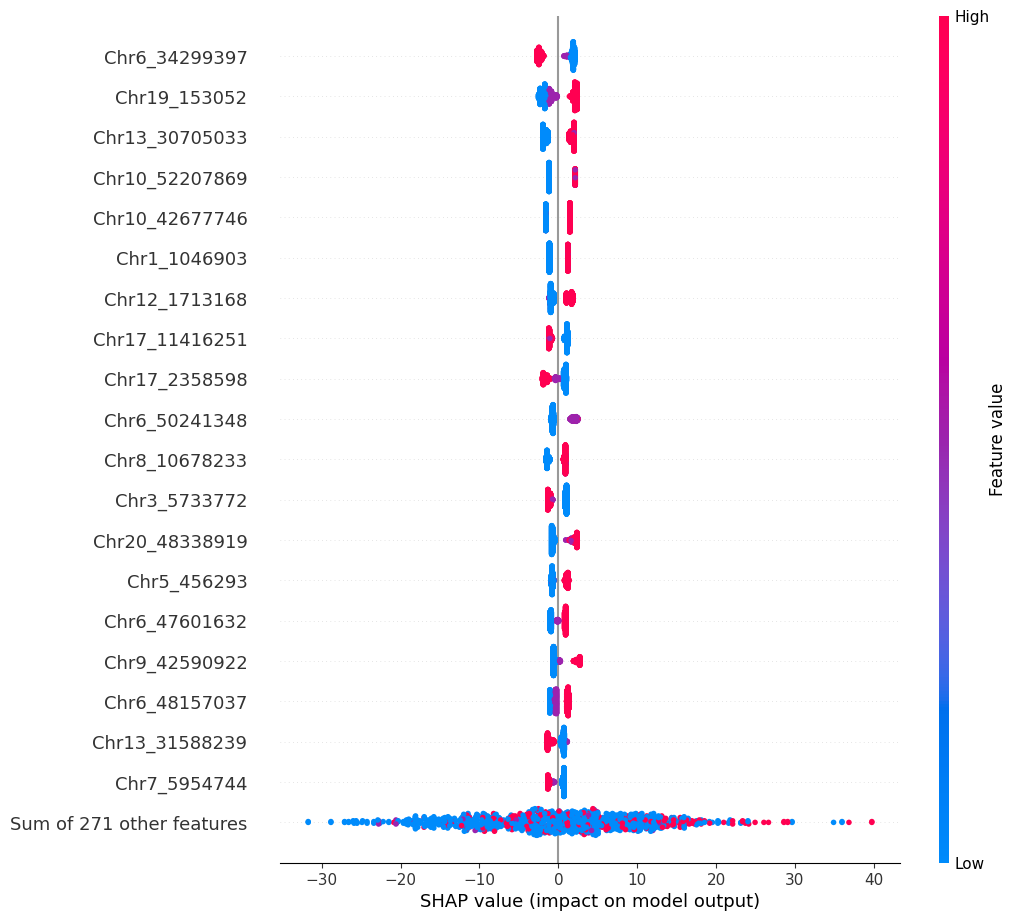

In [110]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])

In [111]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [112]:
holdout_data = holdout_data.set_index('Line')

In [52]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [53]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [54]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [55]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 290 entries, Chr1_1046903 to Chr20_50084112
dtypes: int64(290)
memory usage: 622.9+ KB


In [56]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.10
RMSE of Holdout: 23.77
Mean of Holdout: 355.60
This is 6.69% of the mean pheno data
0 355.712 374.584
1 344.136 356.98886
2 351.481 367.5731
3 353.611 368.3529
4 390.342 357.26437


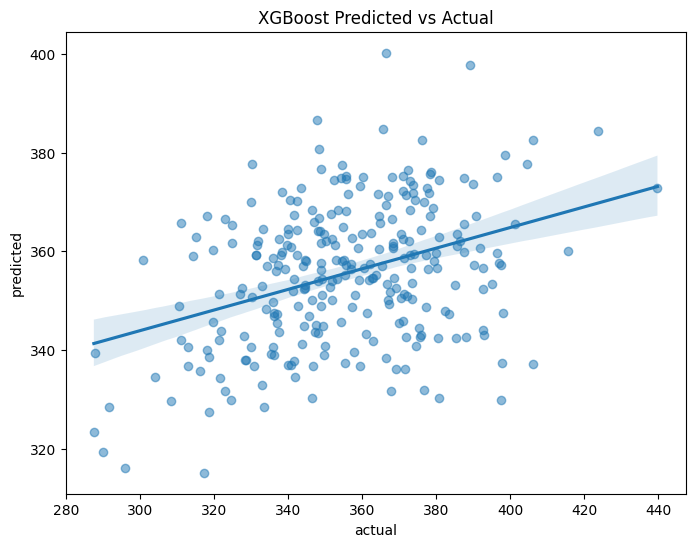

In [57]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [119]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 1), ('min_samples_split', 11), ('n_estimators', 170)])


In [120]:
best_rfr_model = eval_k_fold(best_rfreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.652030711042456
RMSE for dataset is:20.712690661015774& mean of this fold is 354.0628818181818
this is 5.850003410312902% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.268739822657226
RMSE for dataset is:22.428104675563038& mean of this fold is 350.36240909090907
this is 6.401401546974631% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.3342455489454865
RMSE for dataset is:21.9889600066983& mean of this fold is 355.2525363636364
this is 6.18967009546989% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.299110181626265
RMSE for dataset is:21.14852224454161& mean of this fold is 358.38728181818175
this is 5.9010247621651795% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.855199521577633
RMSE for datas

In [121]:
pickle.dump(best_rfr_model, open("lasso_onlysnps_rfr_prt.pickle.dat", "wb"))

In [59]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/lasso_onlysnps_rfr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.17
RMSE of Holdout: 22.84
Mean of Holdout: 355.60
This is 6.42% of the mean pheno data
0 355.712 364.05276721290727
1 344.136 355.6168504882536
2 351.481 361.05793871508337
3 353.611 363.6758515359069
4 390.342 357.8414973376134


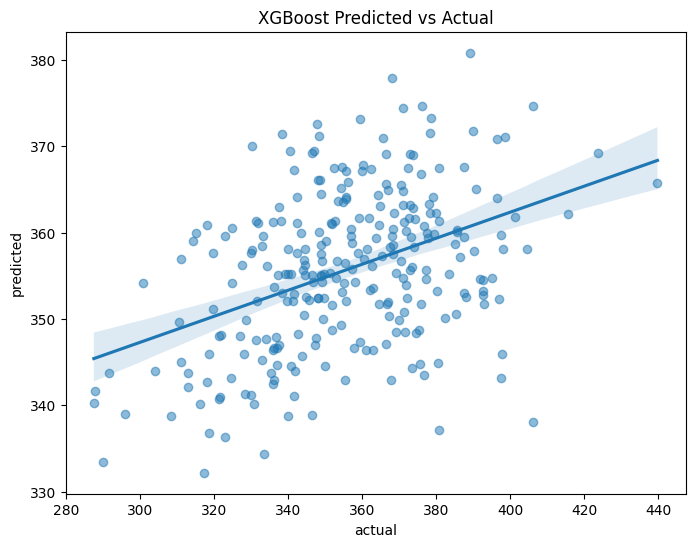

In [60]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [123]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [124]:
best_svr_model = eval_k_fold(best_svreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.530765026220223
RMSE for dataset is:21.302709862553588& mean of this fold is 352.97283636363636
this is 6.035226416292077% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.007589688220472
RMSE for dataset is:22.083447146980358& mean of this fold is 356.91818181818184
this is 6.187257548630547% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6750131729341311
RMSE for dataset is:16.294409067273968& mean of this fold is 355.7102181818182
this is 4.580809949897256% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.6888878668469545
RMSE for dataset is:17.76244379196113& mean of this fold is 351.46119999999996
this is 5.053884693946624% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.2054856341283222
RMSE for 

In [125]:
pickle.dump(best_svr_model, open("lasso_onlysnps_svr_prt.pickle.dat", "wb"))

In [61]:
best_svr_model = pickle.load(open("../pickle_bestmodels/lasso_onlysnps_svr_prt.pickle.dat", "rb"))

R^2 Value of Holdout: 0.16
RMSE of Holdout: 22.96
Mean of Holdout: 355.60
This is 6.46% of the mean pheno data
0 355.712 368.21013081514616
1 344.136 358.8969124498217
2 351.481 361.8732491245529
3 353.611 367.5792641715075
4 390.342 356.33161643669456


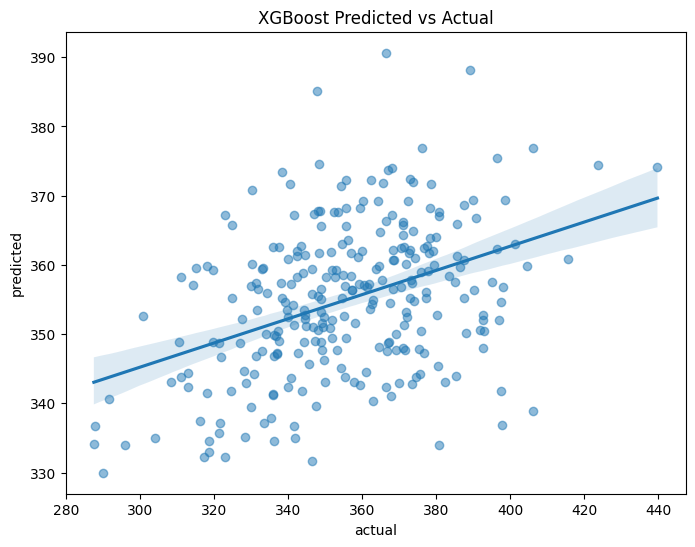

In [62]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)